# Bacterial Colony Classification Using Deep Learning

### Investigating Generalization to Unseen Bacterial Strains

## 1. Introduction



Bacterial colony images contain visual characteristics that can help distinguish between bacterial species. Deep learning provides a way to automate this classification from images.

This project investigates how well a CNN can classify bacterial species and, more importantly, whether it can generalize to bacterial strains that were not seen during training.


### 1.1 Background

Bacterial colony morphology provides visual features that can be used for species classification, including colony shape, size, colour, surface texture, edge structure, and hemolysis. These features can vary not only between species but also between strains of the same species. The dataset used in this project contains high-resolution images covering 19 bacterial species and 151 strains, providing variation in colony morphology for classification and generalization analysis.

### 1.2 Problem Statement

A classification model may achieve high performance when images from the same bacterial strains are present in both the training and test sets. However, this does not show how well the model generalizes to strains that were not seen during training. Since colony morphology can vary between strains of the same species, evaluating performance on unseen strains is important for assessing the model's generalization ability.

### 1.3 Research Question

How well does a **ResNet-18 convolutional neural network** classify bacterial species under two different data splitting strategies: **Experiment 1, using previously unseen strains for testing, and Experiment 2, using a random image level split**?

The comparison aims to determine how the choice of data splitting strategy affects the measured classification performance and the model's ability to generalize.


# 2. Dataset

### 2.1 Dataset Access and Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

save_dir = "/content/drive/MyDrive/T7_project/Datasets"
os.makedirs(save_dir, exist_ok=True)

In [ ]:
files = {
    "images.zip": "https://zenodo.org/records/18256864/files/images.zip?download=1$0",
    "images_agu.zip": "https://zenodo.org/records/18256864/files/images_agu.zip?download=1$0",
    "label.zip": "https://zenodo.org/records/18256864/files/label.zip?download=1$0",
    "label_agu.zip": "https://zenodo.org/records/18256864/files/label_agu.zip?download=1$0",
}

In [ ]:

#for filename, url in files.items():
    #dest = os.path.join(save_dir, filename)

    #print(f"Downloading {filename}...")

    #!wget -c --show-progress -O "{dest}" "{url}"

#print("All downloads complete.")

In [ ]:
# #import zipfile

# #stored_files = {
#     "images.zip": "images",
#     "images_agu.zip": "images_agu",
#     "label.zip": "label",
#     "label_agu.zip": "label_agu"
# }


# extracted_dir =os.path.join(save_dir,"Extracted")
# os.makedirs(extracted_dir,exist_ok=True)

# for zip_name, folder in stored_files.items():
#   zip_path =os.path.join(save_dir,zip_name)
#   extract_path =os.path.join(extracted_dir,folder)
#   os.makedirs(extract_path,exist_ok=True)

#   print(f"Extracting {zip_name}..................")

#   with zipfile.ZipFile(zip_path, 'r') as zip_ref :
#     zip_ref.extractall(extract_path)


# print("Extraction complete.")


### 2.2 Dataset Exploration

In [ ]:
import pandas as pd

In [ ]:
base_dir = "/content/drive/MyDrive/T7_project/Datasets/Extracted"
original_dir = os.path.join(base_dir,"images","images","aba")
augmented_dir = os.path.join(base_dir,"images_agu","images_agu","aba_agu")
excel_path = os.path.join(base_dir,"Bacterial_Image_Records.xlsx")

In [ ]:
excel_df = pd.read_excel(excel_path)
excel_df.head()

,Image filename,Augmentation method,Isolate number,Hemolysis characteristics,Colony-forming unit
0,aba_01.jpg,Vertical flip,aba_01,No hemolysis,5
1,aba_02.jpg,Vertical flip,aba_02,No hemolysis,12
2,aba_03.jpg,Horizontal flip,aba_02,No hemolysis,8
3,aba_04.jpg,Vertical flip,aba_03,No hemolysis,16
4,aba_05.jpg,Vertical flip,aba_03,No hemolysis,31


In [ ]:
excel_df.columns

In [ ]:


excel_df["Image filename"] = excel_df["Image filename"].astype("str")

In [ ]:
[folder for folder in os.listdir(base_dir)]

['images', 'images_agu', 'label', 'label_agu', 'Bacterial_Image_Records.xlsx']

In [ ]:
path=os.path.join(base_dir,"images","images")
path

'/content/drive/MyDrive/T7_project/Datasets/Extracted/images/images'

In [ ]:
species_list = sorted([folder for folder in os.listdir(os.path.join(base_dir,"images","images"))])
species_list

['aba',
 'bce',
 'bcp',
 'cst',
 'eca',
 'eco',
 'efa',
 'enc',
 'kpn',
 'mmo',
 'ppu',
 'sag',
 'sau',
 'sep',
 'ses',
 'sma',
 'spn',
 'spy',
 'stm']

In [ ]:
print("Number of species:", len(species_list))

Number of species: 19


### 2.3 Dataset Integration

In [ ]:

all_image_rows =[]

for species in species_list:
  original_dir =os.path.join(base_dir,"images", "images", species)
  augmented_dir =os.path.join(base_dir,"images_agu", "images_agu", species+"_agu")

  # Original images

  for filename in os.listdir(original_dir):
    all_image_rows.append({
                    "image_filename": filename,
                    "original_filename": filename,
                    "species": species,
                    "image_type": "original",
                    "augmentation": "none"
                })



  #Augmented images

  for filename in os.listdir(augmented_dir):
    if filename.endswith("_Hor.jpg"):
      original_filename =filename.replace("_Hor.jpg",".jpg")
      augmentation = "horizontal"

    elif filename.endswith("_Ver.jpg"):
      original_filename =filename.replace("_Ver.jpg",".jpg")
      augmentation = "vertical"

    all_image_rows.append({
                "image_filename": filename,
                "original_filename": original_filename,
                "species": species,
                "image_type": "augmented",
                "augmentation": augmentation
            })




image_df =pd.DataFrame(all_image_rows)



In [ ]:
len(image_df)

1900

In [ ]:
image_df

,image_filename,original_filename,species,image_type,augmentation
0,aba_01.jpg,aba_01.jpg,aba,original,none
1,aba_02.jpg,aba_02.jpg,aba,original,none
2,aba_03.jpg,aba_03.jpg,aba,original,none
3,aba_04.jpg,aba_04.jpg,aba,original,none
4,aba_05.jpg,aba_05.jpg,aba,original,none
...,...,...,...,...,...
1895,stm_46_Hor.jpg,stm_46.jpg,stm,augmented,horizontal
1896,stm_47_Hor.jpg,stm_47.jpg,stm,augmented,horizontal
1897,stm_48_Ver.jpg,stm_48.jpg,stm,augmented,vertical
1898,stm_49_Ver.jpg,stm_49.jpg,stm,augmented,vertical


In [ ]:
excel_strain = excel_df[["Image filename","Isolate number"]].copy()
excel_strain

,Image filename,Isolate number
0,aba_01.jpg,aba_01
1,aba_02.jpg,aba_02
2,aba_03.jpg,aba_02
3,aba_04.jpg,aba_03
4,aba_05.jpg,aba_03
...,...,...
945,bcp_46.jpg,bcp_05
946,bcp_47.jpg,bcp_05
947,bcp_48.jpg,bcp_05
948,bcp_49.jpg,bcp_05


In [ ]:
master_df = image_df.merge(
    excel_strain,
    left_on="original_filename",
    right_on="Image filename",
    how="left"
)


master_df = master_df.rename(
    columns={"Isolate number": "strain"}
)
master_df


,image_filename,original_filename,species,image_type,augmentation,Image filename,strain
0,aba_01.jpg,aba_01.jpg,aba,original,none,aba_01.jpg,aba_01
1,aba_02.jpg,aba_02.jpg,aba,original,none,aba_02.jpg,aba_02
2,aba_03.jpg,aba_03.jpg,aba,original,none,aba_03.jpg,aba_02
3,aba_04.jpg,aba_04.jpg,aba,original,none,aba_04.jpg,aba_03
4,aba_05.jpg,aba_05.jpg,aba,original,none,aba_05.jpg,aba_03
...,...,...,...,...,...,...,...
1895,stm_46_Hor.jpg,stm_46.jpg,stm,augmented,horizontal,stm_46.jpg,stm_05
1896,stm_47_Hor.jpg,stm_47.jpg,stm,augmented,horizontal,stm_47.jpg,stm_05
1897,stm_48_Ver.jpg,stm_48.jpg,stm,augmented,vertical,stm_48.jpg,stm_05
1898,stm_49_Ver.jpg,stm_49.jpg,stm,augmented,vertical,stm_49.jpg,stm_05


In [ ]:
master_df = master_df.drop(
    columns=["Image filename"]
)

In [ ]:
print(master_df.head(10))
print("Rows:", len(master_df))
print("Missing strains:", master_df["strain"].isna().sum())

  image_filename original_filename species image_type augmentation  strain
0     aba_01.jpg        aba_01.jpg     aba   original         none  aba_01
1     aba_02.jpg        aba_02.jpg     aba   original         none  aba_02
2     aba_03.jpg        aba_03.jpg     aba   original         none  aba_02
3     aba_04.jpg        aba_04.jpg     aba   original         none  aba_03
4     aba_05.jpg        aba_05.jpg     aba   original         none  aba_03
5     aba_06.jpg        aba_06.jpg     aba   original         none  aba_03
6     aba_07.jpg        aba_07.jpg     aba   original         none  aba_03
7     aba_08.jpg        aba_08.jpg     aba   original         none  aba_04
8     aba_09.jpg        aba_09.jpg     aba   original         none  aba_04
9     aba_10.jpg        aba_10.jpg     aba   original         none  aba_04
Rows: 1900
Missing strains: 0


### 2.4 Exploratory Data Analysis

In [ ]:
#Do we have exactly 950 original images and 950 augmented images?
original_img_count=len(master_df[master_df["image_type"]=="original"])
aug_img_count = len(master_df[master_df["image_type"]=="augmented"])

print(original_img_count)
print(aug_img_count)

950
950


In [ ]:
#Are there exactly 19 bacterial species?
master_df["species"].nunique()

19

In [ ]:
#Does every species have 50 original images and 50 augmented images?

master_df["species"].value_counts()

,count
species,
aba,100
bce,100
bcp,100
cst,100
eca,100
eco,100
efa,100
enc,100
kpn,100


In [ ]:
#Does every image have a correctly mapped strain?

master_df["strain"].isna().sum()

np.int64(0)

In [ ]:
master_df["strain"].nunique()

151

In [ ]:
#Are there any duplicate image filenames?

master_df["image_filename"].nunique() == len(master_df["image_filename"])

True

In [ ]:
#Does every augmented image correctly map back to its original image?

augmented = master_df[master_df["image_filename"].str.contains("_Ver|_Hor", na=False)]
augmented



,image_filename,original_filename,species,image_type,augmentation,strain
50,aba_01_Ver.jpg,aba_01.jpg,aba,augmented,vertical,aba_01
51,aba_02_Ver.jpg,aba_02.jpg,aba,augmented,vertical,aba_02
52,aba_03_Hor.jpg,aba_03.jpg,aba,augmented,horizontal,aba_02
53,aba_04_Ver.jpg,aba_04.jpg,aba,augmented,vertical,aba_03
54,aba_05_Ver.jpg,aba_05.jpg,aba,augmented,vertical,aba_03
...,...,...,...,...,...,...
1895,stm_46_Hor.jpg,stm_46.jpg,stm,augmented,horizontal,stm_05
1896,stm_47_Hor.jpg,stm_47.jpg,stm,augmented,horizontal,stm_05
1897,stm_48_Ver.jpg,stm_48.jpg,stm,augmented,vertical,stm_05
1898,stm_49_Ver.jpg,stm_49.jpg,stm,augmented,vertical,stm_05


In [ ]:
augmented["original_filename"] = augmented["image_filename"].str.replace("_Ver", "", regex=False).str.replace("_Hor", "", regex=False)
augmented

/tmp/ipykernel_3757/3855503409.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  augmented["original_filename"] = augmented["image_filename"].str.replace("_Ver", "", regex=False).str.replace("_Hor", "", regex=False)


,image_filename,original_filename,species,image_type,augmentation,strain
50,aba_01_Ver.jpg,aba_01.jpg,aba,augmented,vertical,aba_01
51,aba_02_Ver.jpg,aba_02.jpg,aba,augmented,vertical,aba_02
52,aba_03_Hor.jpg,aba_03.jpg,aba,augmented,horizontal,aba_02
53,aba_04_Ver.jpg,aba_04.jpg,aba,augmented,vertical,aba_03
54,aba_05_Ver.jpg,aba_05.jpg,aba,augmented,vertical,aba_03
...,...,...,...,...,...,...
1895,stm_46_Hor.jpg,stm_46.jpg,stm,augmented,horizontal,stm_05
1896,stm_47_Hor.jpg,stm_47.jpg,stm,augmented,horizontal,stm_05
1897,stm_48_Ver.jpg,stm_48.jpg,stm,augmented,vertical,stm_05
1898,stm_49_Ver.jpg,stm_49.jpg,stm,augmented,vertical,stm_05


In [ ]:
augmented["original_filename"].isin(master_df["image_filename"]).all()

np.True_

In [ ]:
#How many distinct strains are there for each species?
master_df.groupby("species")["strain"].nunique()

,strain
species,
aba,11
bce,7
bcp,5
cst,6
eca,7
eco,9
efa,11
enc,8
kpn,14


In [ ]:

total_strain_count=master_df.groupby(["species","strain"]).size().reset_index(name="img_count")
total_strain_count

,species,strain,img_count
0,aba,aba_01,2
1,aba,aba_02,8
2,aba,aba_03,8
3,aba,aba_04,20
4,aba,aba_05,14
...,...,...,...
146,stm,stm_03,18
147,stm,stm_04,10
148,stm,stm_05,28
149,stm,stm_06,4


In [ ]:
#Which species have at least 4 distinct strains?

master_df.groupby("species")["strain"].nunique()[master_df.groupby("species")["strain"].nunique() >=4]

,strain
species,
aba,11
bce,7
bcp,5
cst,6
eca,7
eco,9
efa,11
enc,8
kpn,14


In [ ]:
#How many original images belong to each strain within each species?
#pd.set_option("display.max_rows", None)

original_strain_count = master_df[master_df["image_type"]=="original"].groupby(["species","strain"]).size().reset_index(name="img_count")
original_strain_count

,species,strain,img_count
0,aba,aba_01,1
1,aba,aba_02,4
2,aba,aba_03,4
3,aba,aba_04,10
4,aba,aba_05,7
...,...,...,...
146,stm,stm_03,9
147,stm,stm_04,5
148,stm,stm_05,14
149,stm,stm_06,2


# 3. Experiment A — Unseen-Strain Data Preparation



**Purpose:** To evaluate whether the ResNet-18 model can generalize to bacterial strains that were not included in the training data.

**Training:** The dataset is split at the **strain level**, so the strains assigned to the test set are completely excluded from training. The training set contains images from the remaining strains, including their allowed augmented versions.

**Testing:** The trained model is then evaluated on images from the held-out strains to measure how well it can classify bacterial species when encountering previously unseen strain variation.


In [ ]:
master_df

,image_filename,original_filename,species,image_type,augmentation,strain
0,aba_01.jpg,aba_01.jpg,aba,original,none,aba_01
1,aba_02.jpg,aba_02.jpg,aba,original,none,aba_02
2,aba_03.jpg,aba_03.jpg,aba,original,none,aba_02
3,aba_04.jpg,aba_04.jpg,aba,original,none,aba_03
4,aba_05.jpg,aba_05.jpg,aba,original,none,aba_03
...,...,...,...,...,...,...
1895,stm_46_Hor.jpg,stm_46.jpg,stm,augmented,horizontal,stm_05
1896,stm_47_Hor.jpg,stm_47.jpg,stm,augmented,horizontal,stm_05
1897,stm_48_Ver.jpg,stm_48.jpg,stm,augmented,vertical,stm_05
1898,stm_49_Ver.jpg,stm_49.jpg,stm,augmented,vertical,stm_05



### 3.1 Strain Level Train-Test Split

In [ ]:
master_df.groupby("species")["strain"].unique()

,strain
species,
aba,"[aba_01, aba_02, aba_03, aba_04, aba_09, aba_0..."
bce,"[bce_04, bce_01, bce_02, bce_03, bce_05, bce_0..."
bcp,"[bcp_01, bcp_02, bcp_03, bcp_04, bcp_05]"
cst,"[cst_01, cst_02, cst_03, cst_04, cst_05, cst_06]"
eca,"[eca_01, eca_02, eca_03, eca_04, eca_05, eca_0..."
eco,"[eco_01, eco_02, eco_03, eco_04, eco_05, eco_0..."
efa,"[efa_01, efa_02, efa_03, efa_04, efa_05, efa_0..."
enc,"[enc_01, enc_02, enc_03, enc_04, enc_05, enc_0..."
kpn,"[kpn_01, kpn_02, kpn_03, kpn_04, kpn_05, kpn_0..."


In [ ]:
master_df.groupby("species")["strain"].nunique()

,strain
species,
aba,11
bce,7
bcp,5
cst,6
eca,7
eco,9
efa,11
enc,8
kpn,14


In [ ]:
strain_count = master_df.groupby(["species", "strain"]).size().reset_index(name="image_count")
strain_count

,species,strain,image_count
0,aba,aba_01,2
1,aba,aba_02,8
2,aba,aba_03,8
3,aba,aba_04,20
4,aba,aba_05,14
...,...,...,...
146,stm,stm_03,18
147,stm,stm_04,10
148,stm,stm_05,28
149,stm,stm_06,4


In [ ]:
master_df

,image_filename,original_filename,species,image_type,augmentation,strain
0,aba_01.jpg,aba_01.jpg,aba,original,none,aba_01
1,aba_02.jpg,aba_02.jpg,aba,original,none,aba_02
2,aba_03.jpg,aba_03.jpg,aba,original,none,aba_02
3,aba_04.jpg,aba_04.jpg,aba,original,none,aba_03
4,aba_05.jpg,aba_05.jpg,aba,original,none,aba_03
...,...,...,...,...,...,...
1895,stm_46_Hor.jpg,stm_46.jpg,stm,augmented,horizontal,stm_05
1896,stm_47_Hor.jpg,stm_47.jpg,stm,augmented,horizontal,stm_05
1897,stm_48_Ver.jpg,stm_48.jpg,stm,augmented,vertical,stm_05
1898,stm_49_Ver.jpg,stm_49.jpg,stm,augmented,vertical,stm_05


In [ ]:
import random

In [ ]:
random.seed(42)
#create the split column
master_df['split']=None

#loop through each species
for species in master_df['species'].unique():
  #get unique strains for this species
  strains=master_df[master_df["species"]==species]["strain"].unique()

  #calculate no of train/test

  n_strain = len(strains)
  n_train = round(n_strain * 0.8)
  n_test = n_strain - n_train

  # Shuffle the strains
  random.shuffle(strains)

  # Select train and test strains
  train_strain = strains[:n_train]
  test_strain = strains[n_train:]

   # Create mapping for this species
  strain_split = {}

  for strain in train_strain:
        strain_split[strain] = "train"

  for strain in test_strain:
        strain_split[strain] = "test"

  # Assign split to the rows of this species
  mask = master_df["species"] == species

  master_df.loc[mask, "split"] = (
    master_df.loc[mask, "strain"].map(strain_split)
)



In [ ]:
master_df

,image_filename,original_filename,species,image_type,augmentation,strain,split
0,aba_01.jpg,aba_01.jpg,aba,original,none,aba_01,train
1,aba_02.jpg,aba_02.jpg,aba,original,none,aba_02,test
2,aba_03.jpg,aba_03.jpg,aba,original,none,aba_02,test
3,aba_04.jpg,aba_04.jpg,aba,original,none,aba_03,train
4,aba_05.jpg,aba_05.jpg,aba,original,none,aba_03,train
...,...,...,...,...,...,...,...
1895,stm_46_Hor.jpg,stm_46.jpg,stm,augmented,horizontal,stm_05,test
1896,stm_47_Hor.jpg,stm_47.jpg,stm,augmented,horizontal,stm_05,test
1897,stm_48_Ver.jpg,stm_48.jpg,stm,augmented,vertical,stm_05,test
1898,stm_49_Ver.jpg,stm_49.jpg,stm,augmented,vertical,stm_05,test


In [ ]:

for species in master_df['species'].unique():
  #get unique strains for this species
  strains=master_df[master_df["species"]==species]["strain"].unique()
  print(strains)
  print(len(strains))

#.loc[row, column] → selects rows using row labels/conditions and columns using column names.
#So .loc selects the rows where the condition is True.

['aba_01' 'aba_02' 'aba_03' 'aba_04' 'aba_09' 'aba_05' 'aba_06' 'aba_07'
 'aba_08' 'aba_10' 'aba_11']
11
['bce_04' 'bce_01' 'bce_02' 'bce_03' 'bce_05' 'bce_06' 'bce_07']
7
['bcp_01' 'bcp_02' 'bcp_03' 'bcp_04' 'bcp_05']
5
['cst_01' 'cst_02' 'cst_03' 'cst_04' 'cst_05' 'cst_06']
6
['eca_01' 'eca_02' 'eca_03' 'eca_04' 'eca_05' 'eca_06' 'eca_07']
7
['eco_01' 'eco_02' 'eco_03' 'eco_04' 'eco_05' 'eco_06' 'eco_07' 'eco_08'
 'eco_09']
9
['efa_01' 'efa_02' 'efa_03' 'efa_04' 'efa_05' 'efa_06' 'efa_07' 'efa_08'
 'efa_09' 'efa_10' 'efa_11']
11
['enc_01' 'enc_02' 'enc_03' 'enc_04' 'enc_05' 'enc_06' 'enc_07' 'enc_08']
8
['kpn_01' 'kpn_02' 'kpn_03' 'kpn_04' 'kpn_05' 'kpn_06' 'kpn_07' 'kpn_08'
 'kpn_09' 'kpn_10' 'kpn_11' 'kpn_12' 'kpn_13' 'kpn_14']
14
['mmo_01' 'mmo_02' 'mmo_03' 'mmo_04' 'mmo_05' 'mmo_06']
6
['ppu_01' 'ppu_02' 'ppu_03' 'ppu_04']
4
['sag_01' 'sag_02' 'sag_03' 'sag_04' 'sag_05']
5
['sau_01' 'sau_02' 'sau_03' 'sau_04' 'sau_05' 'sau_06' 'sau_07' 'sau_08'
 'sau_09' 'sau_10']
10
['sep_01' 's

In [ ]:
master_df["split"].value_counts().sum()

np.int64(1900)

In [ ]:
master_df.groupby(["species", "split"])["strain"].nunique()

species  split
aba      test      2
         train     9
bce      test      1
         train     6
bcp      test      1
         train     4
cst      test      1
         train     5
eca      test      1
         train     6
eco      test      2
         train     7
efa      test      2
         train     9
enc      test      2
         train     6
kpn      test      3
         train    11
mmo      test      1
         train     5
ppu      test      1
         train     3
sag      test      1
         train     4
sau      test      2
         train     8
sep      test      2
         train     8
ses      test      2
         train     6
sma      test      2
         train    10
spn      test      1
         train     4
spy      test      1
         train     5
stm      test      1
         train     6
Name: strain, dtype: int64

In [ ]:
master_df[master_df["augmentation"] == "none"]["split"].value_counts()

,count
split,
train,764
test,186


In [ ]:
master_df.rename(columns={"split": "split_Exp_A_strain"}, inplace=True)
master_df

,image_filename,original_filename,species,image_type,augmentation,strain,split_Exp_A_strain
0,aba_01.jpg,aba_01.jpg,aba,original,none,aba_01,train
1,aba_02.jpg,aba_02.jpg,aba,original,none,aba_02,test
2,aba_03.jpg,aba_03.jpg,aba,original,none,aba_02,test
3,aba_04.jpg,aba_04.jpg,aba,original,none,aba_03,train
4,aba_05.jpg,aba_05.jpg,aba,original,none,aba_03,train
...,...,...,...,...,...,...,...
1895,stm_46_Hor.jpg,stm_46.jpg,stm,augmented,horizontal,stm_05,test
1896,stm_47_Hor.jpg,stm_47.jpg,stm,augmented,horizontal,stm_05,test
1897,stm_48_Ver.jpg,stm_48.jpg,stm,augmented,vertical,stm_05,test
1898,stm_49_Ver.jpg,stm_49.jpg,stm,augmented,vertical,stm_05,test


In [ ]:
#check train/test strains don't overlap
train_strains_A = set(
    master_df[master_df["split_Exp_A_strain"] == "train"]["strain"]       #unique strains in train
)

test_strains_A = set(
    master_df[master_df["split_Exp_A_strain"] == "test"]["strain"]     #unique strains in test
)

train_strains_A.intersection(test_strains_A) #intersection i szero so no overlap


set()

In [ ]:
#check augmented versions follow their strain
check_A = master_df.groupby(
    "strain"
)["split_Exp_A_strain"].nunique()

check_A.value_counts()

,count
split_Exp_A_strain,
1,151


# 4. Experiment B — Random Image-Level Data Preparation

**Purpose**

To evaluate the ResNet-18 model using a conventional **random image-level train-test split**, providing a comparison with the unseen-strain experiment.

**Training**

The original images are randomly divided into training and testing sets for each species. The corresponding augmented images remain in the same split as their original images to prevent data leakage.

**Testing**

The trained model is evaluated on the held-out images from the same set of bacterial strains represented in the training data.


### 4.1 Random Image Level Train-Test Split

In [ ]:
random.seed(42)

# Create the new column first
master_df["split_Exp_B_random"] = None

# Loop through every species

for species in master_df["species"].unique():
   # Get original images for this species
    original_df = master_df[
        (master_df["species"] == species) &
        (master_df["image_type"] == "original")
    ]

     # Get original filenames
    images = original_df["original_filename"].tolist()
    # Shuffle images
    random.shuffle(images)

    # Calculate 80/20 split
    n_images = len(images)
    n_train = round(n_images * 0.8)

    # Select train and test images
    train_images = images[:n_train]
    test_images = images[n_train:]

    # Create image → split mapping
    image_split = {}

    for image in train_images:
        image_split[image] = "train"

    for image in test_images:
        image_split[image] = "test"


     # Apply the mapping to ALL images of this species
    mask = master_df["species"] == species

    master_df.loc[mask, "split_Exp_B_random"] = (
        master_df.loc[mask, "original_filename"].map(image_split)
    )

In [ ]:
master_df

,image_filename,original_filename,species,image_type,augmentation,strain,split_Exp_A_strain,split_Exp_B_random
0,aba_01.jpg,aba_01.jpg,aba,original,none,aba_01,train,train
1,aba_02.jpg,aba_02.jpg,aba,original,none,aba_02,test,test
2,aba_03.jpg,aba_03.jpg,aba,original,none,aba_02,test,train
3,aba_04.jpg,aba_04.jpg,aba,original,none,aba_03,train,train
4,aba_05.jpg,aba_05.jpg,aba,original,none,aba_03,train,train
...,...,...,...,...,...,...,...,...
1895,stm_46_Hor.jpg,stm_46.jpg,stm,augmented,horizontal,stm_05,test,train
1896,stm_47_Hor.jpg,stm_47.jpg,stm,augmented,horizontal,stm_05,test,test
1897,stm_48_Ver.jpg,stm_48.jpg,stm,augmented,vertical,stm_05,test,test
1898,stm_49_Ver.jpg,stm_49.jpg,stm,augmented,vertical,stm_05,test,train


In [ ]:
#check original images are 80/20
master_df[
    master_df["image_type"] == "original"
]["split_Exp_B_random"].value_counts()

,count
split_Exp_B_random,
train,760
test,190


In [ ]:
# making sure that an original image and all of its augmented versions stay in the same split in Experiment B.
check_B = master_df.groupby(
    "original_filename"
)["split_Exp_B_random"].nunique()

check_B.value_counts()

,count
split_Exp_B_random,
1,950


# 5. Image Preprocessing and Data Pipeline


## 5.1 Model 1

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image #image → now contains the image in a format PyTorch can work with ,We can then resize, inspect, convert, or preprocess the image.



The training set contains both original and augmented images, while the test set contains only original images. This keeps the evaluation based on the original data and avoids using augmented images as test samples.

In [ ]:
train_df1 = master_df[master_df['split_Exp_A_strain']=='train']
test_df1 = master_df[(master_df['split_Exp_A_strain']=='test') & (master_df["image_type"]=="original")]

In [ ]:
print(train_df1["species"].value_counts())
print(test_df1["species"].value_counts())

species
efa    96
ppu    94
bcp    92
sma    88
bce    88
sep    88
ses    86
spn    86
aba    84
kpn    84
cst    78
sau    78
mmo    78
stm    72
spy    72
enc    70
sag    70
eco    66
eca    58
Name: count, dtype: int64
species
eca    21
eco    17
enc    15
sag    15
stm    14
spy    14
mmo    11
sau    11
cst    11
aba     8
kpn     8
spn     7
ses     7
sep     6
bce     6
sma     6
bcp     4
ppu     3
efa     2
Name: count, dtype: int64


In [ ]:
classes = sorted(master_df['species'].unique())
class_to_index = {class_name: idx for idx, class_name in enumerate(classes)}  #dict comprehension
class_to_index

{'aba': 0,
 'bce': 1,
 'bcp': 2,
 'cst': 3,
 'eca': 4,
 'eco': 5,
 'efa': 6,
 'enc': 7,
 'kpn': 8,
 'mmo': 9,
 'ppu': 10,
 'sag': 11,
 'sau': 12,
 'sep': 13,
 'ses': 14,
 'sma': 15,
 'spn': 16,
 'spy': 17,
 'stm': 18}


### 5.1.1 Resize and Padding

The original plate images are **4056 × 3040 pixels**. To prepare them for ResNet-18, each image is resized proportionally while preserving its original aspect ratio. This reduces the image resolution without cropping or removing any part of the plate, although some pixel-level detail is lost during the resizing process. Padding is then added to the resized image to produce a final input size of **224 × 224 pixels**. This preserves the complete plate while providing a consistent input size for the model.

In [ ]:
# __call__() is a special Python method that allows a class object
# to be used like a function. When the object is called, Python
# automatically executes the __call__() method.
# We use a callable class for our custom ResizeWithPadding transformation so that it can be used inside transforms.Compose() along with other PyTorch transformations.
# The class stores the target size and __call__() allows the transformation to be applied automatically when an image passes through the pipeline.

In [ ]:
class ResizeWithPadding:
  # Store the desired final image size
  def __init__(self,target_size):
    self.target_size = target_size

   # Apply the resize + padding operation to an image
  def __call__(self,image):
      # Get the original image dimensions
    original_width,original_height = image.size
      # Get the required final dimensions
    target_width,target_height = self.target_size

      # Calculate the scale that keeps the entire image
      #  The minimum scale is used to ensure that both the width and height fit within the 224 × 224 target size without cropping.

    scale = min(target_width/original_width, target_height/original_height)

      # Calculate the new dimensions after proportional resizing
    resized_width = int(original_width * scale)
    resized_height =int(original_height * scale)

     # Resize the image while preserving its aspect ratio
    image =F.resize(image,(resized_height,resized_width))
    # Calculate the total padding needed on each dimension
    total_horizontal_padding = target_width - resized_width
    total_vertical_padding = target_height - resized_height
    # Divide the horizontal padding between left and right
    padding_left = total_horizontal_padding//2
    padding_right = total_horizontal_padding - padding_left

    # Divide the vertical padding between top and bottom
    padding_top = total_vertical_padding // 2
    padding_bottom = total_vertical_padding - padding_top

     # Add the calculated padding
     # fill=0 means the padding area will be black

     #For torchvision.transforms.functional.pad(), the padding list is written in this order:[left, top, right, bottom]
    image = F.pad(image, [padding_left,padding_top,padding_right,padding_bottom], fill =0)
      # Return the final 224 × 224 image
    return image



# Create the resize + padding transform with a target size of 224 × 224
resize_and_pad = ResizeWithPadding((224, 224))


In [ ]:
# ImageNet normalization values for the three RGB channels
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

# Normalization formula:
# normalized_pixel = (pixel_value - mean) / standard_deviation
#
# The normalization is performed separately for each channel:
# Red   → (pixel - 0.485) / 0.229
# Green → (pixel - 0.456) / 0.224
# Blue  → (pixel - 0.406) / 0.225

image_transform = transforms.Compose([
    resize_and_pad,
    transforms.ToTensor(),
    transforms.Normalize(mean=mean,std=std)

])

In [ ]:
# The Pandas DataFrames (train_df and test_df) contain the information
# about each image, such as its file path, species, strain, and split.

# However, the DataFrames only store information about the images;
# they do not load the actual image data into PyTorch.
#
# We create a custom PyTorch Dataset to connect each row in the DataFrame
# with its corresponding image file.

# For each image, the Dataset will:
# 1. Read the image from its file path.
# 2. Convert the species name into a numerical class label.
# 3. Apply the defined image preprocessing transformations.
# 4. Return the processed image and its corresponding label to the model.

# This allows the PyTorch DataLoader to load the images in batches
# during training and testing.

In [ ]:
path = "/content/drive/MyDrive/T7_project/Datasets/Extracted"

In [ ]:
#Create the PyTorch Dataset

class BacterialColonyDataset(Dataset):
  def __init__(self,dataframe,original_root,augmented_root,transform=None):
    self.dataframe = dataframe.reset_index(drop =True)
    self.original_root = original_root
    self.augmented_root = augmented_root
    self.transform = transform

  def __len__(self):
    return len(self.dataframe)


  def __getitem__(self, index):
    row =self.dataframe.iloc[index]
    image_filename = row["image_filename"]
    species = row["species"]
    image_type = row["image_type"]


    if image_type == "original":
      image_root = self.original_root
      species_folder = species
    else:
      image_root = self.augmented_root
      species_folder = species + "_agu"


    image_path = os.path.join(image_root,species_folder,image_filename)
    image = Image.open(image_path).convert("RGB")

    if self.transform:
      image = self.transform(image)

    label = class_to_index[species]

    return image, label

In [ ]:
# Main folders containing the original and augmented images
original_root = os.path.join(path, "images", "images")
augmented_root = os.path.join(path, "images_agu", "images_agu")


# Create the training Dataset
train_dataset1 = BacterialColonyDataset(
    dataframe=train_df1,
    original_root=original_root,
    augmented_root=augmented_root,
    transform = image_transform
)

In [ ]:
# Create DataLoaders
# The Dataset loads one image and label at a time.
# DataLoader groups these samples into batches for the model.
# Training data is shuffled, while test data is not shuffled.
# Batch size determines how many images are processed at once.

batch_size = 64

train_dataloader1 = DataLoader( train_dataset1,
                              batch_size=batch_size,
                              shuffle =True,
                              num_workers=2)

In [ ]:
#Check the Data Pipeline

images, labels = next(iter(train_dataloader1))

print("Image batch shape:", images.shape)
print("Labels shape:", labels.shape)
print("Labels:", labels)

Image batch shape: torch.Size([64, 3, 224, 224])
Labels shape: torch.Size([64])
Labels: tensor([ 6,  0,  4, 17, 16,  2,  1, 16, 14, 14,  9, 13, 13,  6,  6,  1,  5,  1,
        16, 10, 15,  8, 10,  8, 13,  5, 18,  1,  2,  7,  2,  2,  5,  3, 11,  6,
         8, 14,  9, 15, 14, 16,  0, 18, 10, 16, 15,  5, 18, 14,  1, 15, 15,  2,
         3,  3, 18,  3,  2,  5, 10,  2,  0, 13])


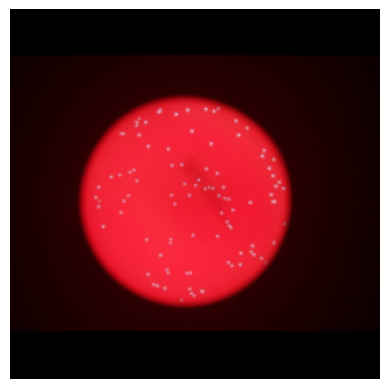

In [ ]:
# Display one image from the loaded batch.
# The image has already been resized, converted to a tensor, and normalized.
# Before displaying it, we temporarily undo the ImageNet normalization so that
# the image appears with its normal RGB colors.
# The mean and standard deviation values are reshaped to [3, 1, 1] so that
# they can be applied separately to the Red, Green, and Blue channels.
# After reversing the normalization, permute() changes the image format from
# [Channels, Height, Width] to [Height, Width, Channels], which is the format
# expected by matplotlib for displaying an RGB image.


image = images[0]

# Undo ImageNet normalization for visualization
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

image = image * std + mean

# Change from PyTorch format [C, H, W] to display format [H, W, C]
image = image.permute(1, 2, 0)

plt.imshow(image)
plt.axis("off")
plt.show()

## 5.2 Model 2

In [ ]:
train_df2= master_df[master_df['split_Exp_B_random']=='train']
test_df2 = master_df[(master_df['split_Exp_B_random']=='test') & (master_df["image_type"]=="original")]

In [ ]:
print(train_df2["species"].value_counts())
print(test_df2["species"].value_counts())

species
aba    80
bce    80
bcp    80
cst    80
eca    80
eco    80
efa    80
enc    80
kpn    80
mmo    80
ppu    80
sag    80
sau    80
sep    80
ses    80
sma    80
spn    80
spy    80
stm    80
Name: count, dtype: int64
species
aba    10
bce    10
bcp    10
cst    10
eca    10
eco    10
efa    10
enc    10
kpn    10
mmo    10
ppu    10
sag    10
sau    10
sep    10
ses    10
sma    10
spn    10
spy    10
stm    10
Name: count, dtype: int64


In [ ]:
classes = sorted(master_df['species'].unique())
class_to_index = {class_name : idx for idx, class_name in enumerate(classes)}
class_to_index

{'aba': 0,
 'bce': 1,
 'bcp': 2,
 'cst': 3,
 'eca': 4,
 'eco': 5,
 'efa': 6,
 'enc': 7,
 'kpn': 8,
 'mmo': 9,
 'ppu': 10,
 'sag': 11,
 'sau': 12,
 'sep': 13,
 'ses': 14,
 'sma': 15,
 'spn': 16,
 'spy': 17,
 'stm': 18}

### 5.2.1 Resize and Padding

In [ ]:
path = "/content/drive/MyDrive/T7_project/Datasets/Extracted"
# Main folders containing the original and augmented images
original_root = os.path.join(path, "images", "images")
augmented_root = os.path.join(path, "images_agu", "images_agu")

In [ ]:
# Create the training Dataset
train_dataset2 = BacterialColonyDataset(
    dataframe=train_df2,
    original_root=original_root,
    augmented_root=augmented_root,
    transform = image_transform
)

# Create the test Dataset
test_dataset2 = BacterialColonyDataset(
    dataframe=test_df2,
    original_root=original_root,
    augmented_root=augmented_root,
    transform=image_transform
)

In [ ]:
batch_size = 64

train_dataloader2 = DataLoader( train_dataset2,
                              batch_size=batch_size,
                              shuffle =True,
                              num_workers=2)

test_dataloader2 = DataLoader(
    test_dataset2,
    batch_size = batch_size,
    shuffle=False,
    num_workers=2
)


In [ ]:

images, labels = next(iter(train_dataloader2))

print("Image batch shape:", images.shape)
print("Labels shape:", labels.shape)
print("Labels:", labels)

Image batch shape: torch.Size([64, 3, 224, 224])
Labels shape: torch.Size([64])
Labels: tensor([ 1,  1,  8, 10, 10,  6, 11,  3, 11, 16,  4,  6,  0,  2, 16, 11, 13, 18,
        12, 12,  1, 16,  3,  0, 10,  7,  0, 17,  0,  8,  4, 16, 15,  3,  8,  0,
         7,  8,  9,  2,  4, 13, 13,  5,  8,  3, 16,  6, 13, 16,  1, 13, 14,  5,
        14,  9, 10,  8, 18, 15,  2, 18, 18, 11])


# 6. Model 1 — ResNet-18 Training (Experiment A)

ResNet-18 is a CNN that uses residual connections to improve the learning of deeper networks. In this project, a pretrained ResNet-18 is used as the base model through transfer learning. The pretrained feature extractor is adapted to the bacterial colony dataset by replacing the final classification layer with a new layer containing 19 output classes, corresponding to the 19 bacterial species.
The model is trained in two stages: first, the pretrained backbone is frozen while the new classification layer is trained; then, the backbone is unfrozen for fine-tuning on the bacterial colony images.

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models #models will give pre built model for training and testing

from sklearn.metrics import  classification_report,confusion_matrix
from torchvision.transforms import functional as F #individual image transformation functions
from tqdm import  tqdm #progress bar

In [ ]:
#  Load Model 1 (ResNet-18) with ImageNet pretrained weights.
# This initializes the pretrained model for transfer learning.
# The model is not being trained yet.

from torchvision.models import resnet18

# Load Model 1 with pretrained ImageNet weights
model1 = resnet18(pretrained=True)

print(model1)

/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 111MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
# Replace the final ResNet-18 layer for our 19 bacterial classes.
# The pretrained model originally has 1000 ImageNet output classes.
# We replace this layer so Model 1 predicts our 19 bacterial species.


#Replace the final classification layer:

# model1.fc refers to the final fully connected (fc) layer of ResNet-18.
# The pretrained ResNet-18 has 512 input features and produces 1000 outputs
# because it was originally trained to classify 1000 ImageNet classes.

# model1.fc.in_features gives us the existing input size of the fc layer (512).
# nn.Linear(512, 19) creates a new fully connected layer that takes
# 512 features as input and produces 19 outputs, one for each bacterial species.

# Assigning this new layer to model1.fc replaces the original 512-to-1000
# classification layer with our new 512-to-19 classification layer.

model1.fc = nn.Linear(model1.fc.in_features, 19)

print(model1.fc)


Linear(in_features=512, out_features=19, bias=True)


In [ ]:
# Freeze the ResNet-18 backbone.
# The pretrained layers will not be updated during training.
# Only the new final classification layer (model1.fc) will learn.

for param in model1.parameters():
  param.requires_grad =False


for param in model1.fc.parameters():
  param.requires_grad = True

In [ ]:
# the model performs 19-class bacterial species classification.
# We use Cross-Entropy Loss to measure the difference between the model's predicted class scores and the correct bacterial species label.
# Cross-Entropy Loss is suitable for multi-class classification with one correct class per image. The model outputs raw logits,
# so Softmax is not added separately because CrossEntropyLoss handles this internally.



**Cross-Entropy Loss**

For each image, ResNet-18 produces **19 logits**, one for each bacterial species. The logits are raw class scores.

Softmax converts these logits into probabilities:

$$
p_i=\frac{e^{z_i}}{\sum_{j=1}^{19}e^{z_j}}
$$

The probabilities sum to 1. Cross-entropy loss measures how well the predicted probabilities match the correct class:

$$
L=-\sum_{i=1}^{19}y_i\log(p_i)
$$

For the correct class, this simplifies to:

$$
L=-\log(p_{\text{true}})
$$

Therefore:

* **High probability for the correct class → low loss**
* **Low probability for the correct class → high loss**




In [ ]:
criterion= nn.CrossEntropyLoss()

In [ ]:
# The optimizer updates the trainable weights of the model to reduce the cross-entropy loss. We use Adam as the optimizer.
# The learning rate controls the size of each weight update. In Stage 1, only the new 19-class classification layer is trainable,
#  while the ResNet-18 backbone remains frozen.

In [ ]:
optimizer1 = torch.optim.Adam(
    model1.fc.parameters(),
    lr=0.001
)

Images + Labels → Forward Pass → 19 Logits → Cross-Entropy Loss → Backpropagation → Gradients → Adam Optimizer → Weight Update

### 6.1 Stage 1 — Frozen Backbone Training




1. Train for **10 epochs** with the ResNet-18 backbone frozen.
2. Train only the new model1.fc classification layer for the **19 bacterial species**.
3. Use the existing training DataLoader containing the training images and labels.
4. For each batch:
   - Clear the previous gradients.
   - Perform the forward pass.
   - Calculate cross-entropy loss.
   - Perform backpropagation.
   - Update the trainable model1.fc weights using Adam.
5. Use a progress bar to monitor each epoch.
6. Calculate and display **training loss and training accuracy** after each epoch.
7. No validation or testing is performed during Stage 1.

**Training flow:**  
Training images → Frozen ResNet-18 backbone → model1.fc → 19 logits → Cross-Entropy Loss → Backpropagation → Adam → Update model1.fc

After Stage 1, the backbone will be unfrozen for **Stage 2**, where the entire Model 1 will be fine-tuned.
```


In [ ]:
train_dataloader1

In [ ]:
import torch

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Using CPU")

CUDA available: False
Using CPU


In [ ]:
# Training function
# This function can be reused for Model 1 and Model 2,
# and for both Stage 1 and Stage 2.

def train_model(model, train_dataloader, criterion, optimizer, num_epochs):

    # Outer loop: repeat the training process for each epoch
    for epoch in range(num_epochs):

        # Put the model into training mode
        model.train()

        # These variables collect results during this epoch
        running_loss = 0.0
        correct = 0
        total = 0

        # tqdm wraps the DataLoader to show training progress
        progress_bar = tqdm(
            train_dataloader,
            desc=f"Epoch: {epoch + 1}/{num_epochs}"
        )

        # Inner loop: process one batch at a time
        for images, labels in progress_bar:

            # Remove gradients left from the previous batch
            optimizer.zero_grad()

            # Forward pass
            outputs = model(images)

            # Compare the model's 19 outputs with the correct labels
            loss = criterion(outputs, labels)

            # Backpropagation
            loss.backward()

            # Update the trainable parameters
            optimizer.step()

            # Add this batch's loss to the running total
            running_loss += loss.item()

            # Find the predicted class for each image
            _, predicted = torch.max(outputs, 1)

            # Number of images in this batch
            total += labels.size(0)

            # Count correct predictions
            correct += (predicted == labels).sum().item()

            # Show the current batch loss
            progress_bar.set_postfix(loss=loss.item())

        # Calculate average loss for this epoch
        epoch_loss = running_loss / len(train_dataloader)

        # Calculate training accuracy for this epoch
        epoch_accuracy = 100 * correct / total

        # Display the results
        print(
            f"Epoch [{epoch + 1}/{num_epochs}] "
            f"Loss: {epoch_loss:.4f} "
            f"Accuracy: {epoch_accuracy:.2f}%"
        )



In [ ]:
model1

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
num_epochs = 10

#train_model(model1, train_dataloader1, criterion, optimizer1, num_epochs)

### 6.2 Stage 2 — Full Model Fine tuning

In [ ]:
# Unfreeze the entire ResNet-18
for param in model1.parameters():
  param.requires_grad =True

In [ ]:
# Create a new optimizer for fine-tuning the entire model
#We use the smaller learning rate 0.0001 for fine-tuning so the pretrained ResNet-18 weights are changed more gradually.

optimizer1 = torch.optim.Adam(
    model1.parameters(),
    lr=0.0001
)

In [ ]:
# Train the entire model
"""
num_epochs = 10

train_model(model1,train_dataloader1,criterion,optimizer1,num_epochs)"""

### 6.3 Model Saving

In [ ]:
"""#save the model only the learned parameters/weights.
torch.save(model1.state_dict(),"/content/drive/MyDrive/T7_project/Model1_ExperimentA_weights.pth")"""

'#save the model only the learned parameters/weights.\ntorch.save(model1.state_dict(),"/content/drive/MyDrive/T7_project/Model1_ExperimentA_weights.pth")'

In [ ]:
"""#saves the model object, so it includes the architecture configuration and the learned parameters.
torch.save(model1, "/content/drive/MyDrive/T7_project/Model1_ExperimentA_full.pth")"""

'#saves the model object, so it includes the architecture configuration and the learned parameters.\ntorch.save(model1, "/content/drive/MyDrive/T7_project/Model1_ExperimentA_full.pth")'

#7. Model 2 — ResNet 18 Training (Experiment B)

ResNet-18 is used as the CNN backbone through transfer learning. For Experiment B, the same pretrained ResNet-18 architecture and two-stage training procedure are used, but the model is trained using the random image-level split. The final classification layer is replaced with a new layer containing 19 output classes, corresponding to the 19 bacterial species. Training is performed in two stages: first, the pretrained backbone is frozen while the new classification layer is trained; then, the backbone is unfrozen and the entire model is fine-tuned on the bacterial colony images.

In [ ]:
master_df

,image_filename,original_filename,species,image_type,augmentation,strain,split_Exp_A_strain,split_Exp_B_random
0,aba_01.jpg,aba_01.jpg,aba,original,none,aba_01,train,train
1,aba_02.jpg,aba_02.jpg,aba,original,none,aba_02,test,test
2,aba_03.jpg,aba_03.jpg,aba,original,none,aba_02,test,train
3,aba_04.jpg,aba_04.jpg,aba,original,none,aba_03,train,train
4,aba_05.jpg,aba_05.jpg,aba,original,none,aba_03,train,train
...,...,...,...,...,...,...,...,...
1895,stm_46_Hor.jpg,stm_46.jpg,stm,augmented,horizontal,stm_05,test,train
1896,stm_47_Hor.jpg,stm_47.jpg,stm,augmented,horizontal,stm_05,test,test
1897,stm_48_Ver.jpg,stm_48.jpg,stm,augmented,vertical,stm_05,test,test
1898,stm_49_Ver.jpg,stm_49.jpg,stm,augmented,vertical,stm_05,test,train


In [ ]:
model2 = resnet18(pretrained=True)
print(model2)

/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

### 7.1 Stage 1 — Frozen Backbone Training

In [ ]:
train_dataloader2

In [ ]:
model2.fc = nn.Linear(model2.fc.in_features,19)

for param in model2.parameters():
  param.requires_grad =False


for param in model2.fc.parameters():
  param.requires_grad = True

In [ ]:
optimizer2 = torch.optim.Adam(
    model2.fc.parameters(),
    lr=0.001
)

In [ ]:
# Train only the classification head (model2.fc)

#num_epochs = 10

#train_model(model2,train_dataloader2,criterion,optimizer2,num_epochs)



In [ ]:
#torch.save(model2.state_dict(),"/content/drive/MyDrive/T7_project/Model2_ExperimentB_weights_final.pth")

### 7.2 Stage 2 — Full Model Fine tuning

In [ ]:
#  Unfreeze the entire ResNet-18

In [ ]:
checkpoint_path = "/content/drive/MyDrive/T7_project/Model2_ExperimentB_weights_final.pth"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model2.load_state_dict(torch.load(checkpoint_path))
model2 = model2.to(device)

In [ ]:
for param in model2.parameters():
  param.requires_grad = True

In [ ]:
optimizer2 = torch.optim.Adam(
    model2.parameters(),
    lr=0.0001
)

In [ ]:
# Train the entire model
#num_epochs = 10

#train_model(model2,train_dataloader2,criterion,optimizer2,num_epochs)

### 7.3 Model Saving

In [ ]:
#save the model only the learned parameters/weights.
#torch.save(model2.state_dict(),"/content/drive/MyDrive/T7_project/Model2_ExperimentB_weights.pth")

In [ ]:
#saves the model object, so it includes the architecture configuration and the learned parameters.
#torch.save(model2, "/content/drive/MyDrive/T7_project/Model2_ExperimentB_full.pth")

# 8. Testing

## 8.1 Model 1

In [ ]:
test_df1

,image_filename,original_filename,species,image_type,augmentation,strain,split_Exp_A_strain,split_Exp_B_random
1,aba_02.jpg,aba_02.jpg,aba,original,none,aba_02,test,test
2,aba_03.jpg,aba_03.jpg,aba,original,none,aba_02,test,train
30,aba_31.jpg,aba_31.jpg,aba,original,none,aba_02,test,train
31,aba_32.jpg,aba_32.jpg,aba,original,none,aba_02,test,train
42,aba_43.jpg,aba_43.jpg,aba,original,none,aba_11,test,train
...,...,...,...,...,...,...,...,...
1845,stm_46.jpg,stm_46.jpg,stm,original,none,stm_05,test,train
1846,stm_47.jpg,stm_47.jpg,stm,original,none,stm_05,test,test
1847,stm_48.jpg,stm_48.jpg,stm,original,none,stm_05,test,test
1848,stm_49.jpg,stm_49.jpg,stm,original,none,stm_05,test,train


In [ ]:
test_df1["species"].value_counts().sort_index() #how mnay test images per species

,count
species,
aba,8
bce,6
bcp,4
cst,11
eca,21
eco,17
efa,2
enc,15
kpn,8


In [ ]:
test_df1.groupby("strain")["species"].first()

,species
strain,
aba_02,aba
aba_11,aba
bce_05,bce
bcp_02,bcp
cst_06,cst
eca_05,eca
eco_05,eco
eco_06,eco
efa_02,efa


In [ ]:
# Create the test Dataset
test_dataset1 = BacterialColonyDataset(
    dataframe=test_df1,
    original_root=original_root,
    augmented_root=augmented_root,
    transform=image_transform
)

In [ ]:
test_dataset1

In [ ]:
batch_size = 64

test_dataloader1 = DataLoader(
    test_dataset1,
    batch_size = batch_size,
    shuffle=False,
    num_workers=2
)

In [ ]:

images, labels = next(iter(test_dataloader1))

print("Image batch shape:", images.shape)
print("Labels shape:", labels.shape)
print("Labels:", labels)

Image batch shape: torch.Size([64, 3, 224, 224])
Labels shape: torch.Size([64])
Labels: tensor([0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3,
        3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
        4, 4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5])


In [ ]:
checkpoint_path = "/content/drive/MyDrive/T7_project/Model1_ExperimentA_weights.pth"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model1.load_state_dict(torch.load(checkpoint_path))
model1 = model1.to(device)


In [ ]:
def test_model(model,test_loader,device):
  model.eval()

  all_true_labels = []
  all_predictions = []
  all_confidences = []

  with torch.no_grad():
    for images, labels in test_loader:
      images = images.to(device)
      labels = labels.to(device)

      outputs = model(images)

      probabilities = torch.softmax(outputs, dim=1)

      confidences, predictions = torch.max(probabilities, dim=1)

      all_true_labels.extend(labels.cpu().numpy())
      all_predictions.extend(predictions.cpu().numpy())
      all_confidences.extend(confidences.cpu().numpy())

  return all_true_labels, all_predictions, all_confidences

In [ ]:
#true_labels1, predictions1, confidences1 = test_model(model1,test_dataloader1,device)

In [ ]:
#print(len(true_labels1))
#print(len(predictions1))
#print(len(confidences1))

### 8.1.1 Test Results and Saving

In [ ]:
class_to_index

{'aba': 0,
 'bce': 1,
 'bcp': 2,
 'cst': 3,
 'eca': 4,
 'eco': 5,
 'efa': 6,
 'enc': 7,
 'kpn': 8,
 'mmo': 9,
 'ppu': 10,
 'sag': 11,
 'sau': 12,
 'sep': 13,
 'ses': 14,
 'sma': 15,
 'spn': 16,
 'spy': 17,
 'stm': 18}

In [ ]:
index_to_class = {
    class_index : species  for species, class_index in class_to_index.items()
}

In [ ]:
results_model1 = test_df1.copy()
results_model1

,image_filename,original_filename,species,image_type,augmentation,strain,split_Exp_A_strain,split_Exp_B_random
1,aba_02.jpg,aba_02.jpg,aba,original,none,aba_02,test,test
2,aba_03.jpg,aba_03.jpg,aba,original,none,aba_02,test,train
30,aba_31.jpg,aba_31.jpg,aba,original,none,aba_02,test,train
31,aba_32.jpg,aba_32.jpg,aba,original,none,aba_02,test,train
42,aba_43.jpg,aba_43.jpg,aba,original,none,aba_11,test,train
...,...,...,...,...,...,...,...,...
1845,stm_46.jpg,stm_46.jpg,stm,original,none,stm_05,test,train
1846,stm_47.jpg,stm_47.jpg,stm,original,none,stm_05,test,test
1847,stm_48.jpg,stm_48.jpg,stm,original,none,stm_05,test,test
1848,stm_49.jpg,stm_49.jpg,stm,original,none,stm_05,test,train


In [ ]:
#results_model1["predicted_species"] = [ index_to_class[class_index] for class_index in predictions1]

In [ ]:
#results_model1["confidence"] = confidences1

In [ ]:
#results_model1["correct"] = (
    #results_model1["species"] ==
    #results_model1["predicted_species"]
#)

In [ ]:
#save_path = '/content/drive/MyDrive/T7_project/results_model1.csv'
#results_model1.to_csv(save_path, index =False)

## 8.2 Model 2

In [ ]:
test_df2

,image_filename,original_filename,species,image_type,augmentation,strain,split_Exp_A_strain,split_Exp_B_random
1,aba_02.jpg,aba_02.jpg,aba,original,none,aba_02,test,test
5,aba_06.jpg,aba_06.jpg,aba,original,none,aba_03,train,test
6,aba_07.jpg,aba_07.jpg,aba,original,none,aba_03,train,test
7,aba_08.jpg,aba_08.jpg,aba,original,none,aba_04,train,test
8,aba_09.jpg,aba_09.jpg,aba,original,none,aba_04,train,test
...,...,...,...,...,...,...,...,...
1839,stm_40.jpg,stm_40.jpg,stm,original,none,stm_05,test,test
1840,stm_41.jpg,stm_41.jpg,stm,original,none,stm_05,test,test
1842,stm_43.jpg,stm_43.jpg,stm,original,none,stm_05,test,test
1846,stm_47.jpg,stm_47.jpg,stm,original,none,stm_05,test,test


In [ ]:
test_df2["species"].value_counts().sort_index() #how mnay test images per species

,count
species,
aba,10
bce,10
bcp,10
cst,10
eca,10
eco,10
efa,10
enc,10
kpn,10


In [ ]:
# Create the test Dataset
test_dataset2 = BacterialColonyDataset(
    dataframe=test_df2,
    original_root=original_root,
    augmented_root=augmented_root,
    transform=image_transform
)

In [ ]:
batch_size = 64

test_dataloader2 = DataLoader(
    test_dataset2,
    batch_size = batch_size,
    shuffle=False,
    num_workers=2
)

In [ ]:

#images, labels = next(iter(test_dataloader2))

#print("Image batch shape:", images.shape)
#print("Labels shape:", labels.shape)
#print("Labels:", labels)

In [ ]:
checkpoint_path = "/content/drive/MyDrive/T7_project/Model2_ExperimentB_weights.pth"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model2.load_state_dict(torch.load(checkpoint_path))
model2 = model2.to(device)

In [ ]:
#true_labels2, predictions2, confidences2 = test_model(model2,test_dataloader2,device)

In [ ]:
# print(len(true_labels2))
# print(len(predictions2))
# print(len(confidences2))

### 8.1.2 Test Results and Saving

In [ ]:
results_model2 = test_df2.copy()

In [ ]:
#results_model2["predicted_species"] = [ index_to_class[class_index] for class_index in predictions2]

In [ ]:
#results_model2["confidence"] = confidences2

In [ ]:
# results_model2["correct"] = (
#     results_model2["species"] ==
#     results_model2["predicted_species"]
# )

In [ ]:
#save_path = '/content/drive/MyDrive/T7_project/results_model2.csv'
#results_model2.to_csv(save_path, index =False)

In [ ]:
#results_model2[results_model2["correct"]== True]

# 9. Performance Visualization and Comparison

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

In [ ]:
results_model1  = pd.read_csv("/content/drive/MyDrive/T7_project/results_model1.csv")
results_model2 = pd.read_csv("/content/drive/MyDrive/T7_project/results_model2.csv")

## 9.1 Accuracy

In [ ]:
#Accuracy = number of correct predictions ÷ total number of predictions × 100.

In [ ]:
#Model 1

accuracy_model1 = results_model1["correct"].mean() * 100
accuracy_model1

np.float64(82.79569892473118)

In [ ]:
#Model 2

accuracy_model2 = results_model2["correct"].mean() * 100

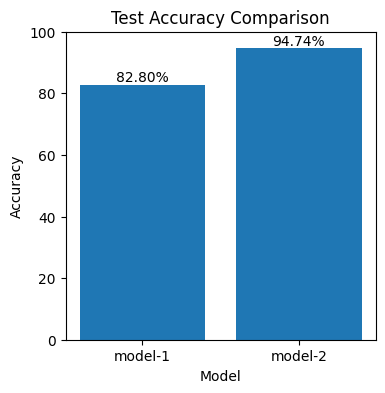

In [ ]:

import matplotlib.pyplot as plt

plt.figure(figsize=(4, 4))

models =["model-1","model-2"]
accuracies =[accuracy_model1,accuracy_model2]
bars = plt.bar(models, accuracies)
plt.bar_label(bars, fmt="%.2f%%")

plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Test Accuracy Comparison")
plt.ylim(0,100)
plt.show()

## 9.2  19-Species Performance

### 9.2.1 Model 1 — 19-Species Performance

In [ ]:
species = sorted(results_model1.species.unique())
species

['aba',
 'bce',
 'bcp',
 'cst',
 'eca',
 'eco',
 'efa',
 'enc',
 'kpn',
 'mmo',
 'ppu',
 'sag',
 'sau',
 'sep',
 'ses',
 'sma',
 'spn',
 'spy',
 'stm']

In [ ]:
results_model1

,image_filename,original_filename,species,image_type,augmentation,strain,split_Exp_A_strain,split_Exp_B_random,predicted_species,confidence,correct
0,aba_02.jpg,aba_02.jpg,aba,original,none,aba_02,test,test,aba,0.998403,True
1,aba_03.jpg,aba_03.jpg,aba,original,none,aba_02,test,train,aba,0.988470,True
2,aba_31.jpg,aba_31.jpg,aba,original,none,aba_02,test,train,aba,0.750025,True
3,aba_32.jpg,aba_32.jpg,aba,original,none,aba_02,test,train,aba,0.979981,True
4,aba_43.jpg,aba_43.jpg,aba,original,none,aba_11,test,train,aba,0.998253,True
...,...,...,...,...,...,...,...,...,...,...,...
181,stm_46.jpg,stm_46.jpg,stm,original,none,stm_05,test,train,stm,0.997278,True
182,stm_47.jpg,stm_47.jpg,stm,original,none,stm_05,test,test,stm,0.999263,True
183,stm_48.jpg,stm_48.jpg,stm,original,none,stm_05,test,test,stm,0.999555,True
184,stm_49.jpg,stm_49.jpg,stm,original,none,stm_05,test,train,stm,0.995795,True


In [ ]:
def metrics(df, species):

    results = []

    for sps in species:

        # True Positive
        tp = len(df[
            (df["species"] == sps) &
            (df["predicted_species"] == sps)
        ])

        # False Positive
        fp = len(df[
            (df["species"] != sps) &
            (df["predicted_species"] == sps)
        ])

        # False Negative
        fn = len(df[
            (df["species"] == sps) &
            (df["predicted_species"] != sps)
        ])



        # Precision
        precision = tp / (tp + fp)

        # Recall
        recall = tp / (tp + fn)




        # F1-score
        f1 = 2 * (precision * recall) / (precision + recall)

        # Number of test images
        no_test_images = len(
            df[df["species"] == sps]
        )

        # Store results
        results.append({
            "species": sps,
            "TP": tp,
            "FP": fp,
            "FN": fn,
            "precision": precision,
            "recall": recall,
            "F1": f1,
            "no_test_images": no_test_images
        })

    return results








In [ ]:
metrics1 = pd.DataFrame(metrics(results_model1,species))
metrics1

,species,TP,FP,FN,precision,recall,F1,no_test_images
0,aba,8,0,0,1.000000,1.000000,1.000000,8
1,bce,6,0,0,1.000000,1.000000,1.000000,6
2,bcp,4,1,0,0.800000,1.000000,0.888889,4
3,cst,4,2,7,0.666667,0.363636,0.470588,11
4,eca,18,5,3,0.782609,0.857143,0.818182,21
5,eco,14,0,3,1.000000,0.823529,0.903226,17
6,efa,1,0,1,1.000000,0.500000,0.666667,2
7,enc,10,0,5,1.000000,0.666667,0.800000,15
8,kpn,8,0,0,1.000000,1.000000,1.000000,8
9,mmo,11,4,0,0.733333,1.000000,0.846154,11


### 9.2.2 Model 2 — 19-Species Performance

In [ ]:
metrics2 = pd.DataFrame(metrics(results_model2,species))
metrics2

,species,TP,FP,FN,precision,recall,F1,no_test_images
0,aba,10,2,0,0.833333,1.0,0.909091,10
1,bce,10,0,0,1.000000,1.0,1.000000,10
2,bcp,9,0,1,1.000000,0.9,0.947368,10
3,cst,9,0,1,1.000000,0.9,0.947368,10
4,eca,7,0,3,1.000000,0.7,0.823529,10
5,eco,10,1,0,0.909091,1.0,0.952381,10
6,efa,10,5,0,0.666667,1.0,0.800000,10
7,enc,10,1,0,0.909091,1.0,0.952381,10
8,kpn,10,0,0,1.000000,1.0,1.000000,10
9,mmo,9,0,1,1.000000,0.9,0.947368,10


In [ ]:
print(metrics1.columns)
print(metrics2.columns)

Index(['species', 'TP', 'FP', 'FN', 'precision', 'recall', 'F1',
       'no_test_images'],
      dtype='object')
Index(['species', 'TP', 'FP', 'FN', 'precision', 'recall', 'F1',
       'no_test_images'],
      dtype='object')


## 9.3  F1 Score

In [ ]:
f1_comparison = metrics1[['species', 'F1']].merge(
    metrics2[['species', 'F1']],
    on='species',
    suffixes=('_Model1', '_Model2')
)

f1_comparison

,species,F1_Model1,F1_Model2
0,aba,1.000000,0.909091
1,bce,1.000000,1.000000
2,bcp,0.888889,0.947368
3,cst,0.470588,0.947368
4,eca,0.818182,0.823529
5,eco,0.903226,0.952381
6,efa,0.666667,0.800000
7,enc,0.800000,0.952381
8,kpn,1.000000,1.000000
9,mmo,0.846154,0.947368


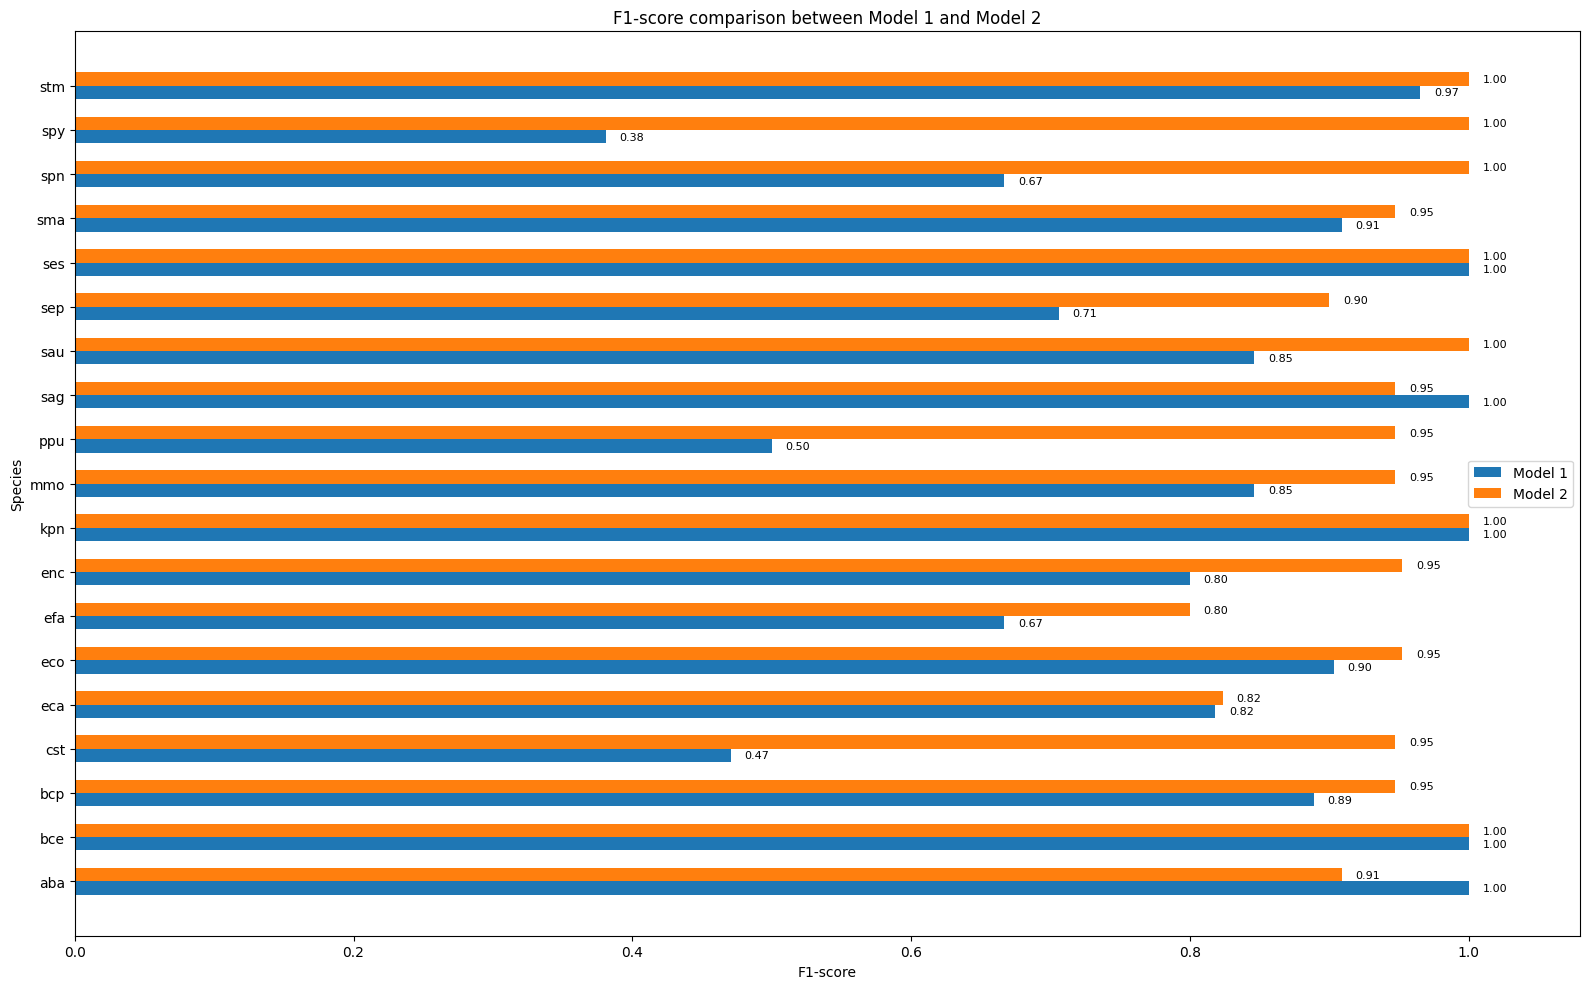

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 10))

y = range(len(f1_comparison))
height = 0.3

bars1 = plt.barh(
    [i - height/2 for i in y],
    f1_comparison['F1_Model1'],
    height=height,
    label='Model 1'
)

bars2 = plt.barh(
    [i + height/2 for i in y],
    f1_comparison['F1_Model2'],
    height=height,
    label='Model 2'
)

# Add F1-score values
for bar in bars1:
    plt.text(
        bar.get_width() + 0.01,
        bar.get_y() + bar.get_height()/2,
        f'{bar.get_width():.2f}',
        va='center',
        fontsize=8
    )

for bar in bars2:
    plt.text(
        bar.get_width() + 0.01, #length of the bar (horizontal) , this is x position
        bar.get_y() + bar.get_height()/2, #get_height - thickness , this is y position
        f'{bar.get_width():.2f}', # the number we are displaying
        va='center',
        fontsize=8
    )

plt.yticks(y, f1_comparison['species']) #display species names on y axis
plt.xlabel('F1-score')
plt.ylabel('Species')
plt.title('F1-score comparison between Model 1 and Model 2')

plt.xlim(0, 1.08)
plt.legend()

plt.tight_layout() #Matplotlib automatically adjusts the margins and spacing.
plt.show()

## 9.4 Confusion Matrix

### 9.4.1 Model 1 — Confusion Matrix

In [ ]:
results_model1

,image_filename,original_filename,species,image_type,augmentation,strain,split_Exp_A_strain,split_Exp_B_random,predicted_species,confidence,correct
0,aba_02.jpg,aba_02.jpg,aba,original,none,aba_02,test,test,aba,0.998403,True
1,aba_03.jpg,aba_03.jpg,aba,original,none,aba_02,test,train,aba,0.988470,True
2,aba_31.jpg,aba_31.jpg,aba,original,none,aba_02,test,train,aba,0.750025,True
3,aba_32.jpg,aba_32.jpg,aba,original,none,aba_02,test,train,aba,0.979981,True
4,aba_43.jpg,aba_43.jpg,aba,original,none,aba_11,test,train,aba,0.998253,True
...,...,...,...,...,...,...,...,...,...,...,...
181,stm_46.jpg,stm_46.jpg,stm,original,none,stm_05,test,train,stm,0.997278,True
182,stm_47.jpg,stm_47.jpg,stm,original,none,stm_05,test,test,stm,0.999263,True
183,stm_48.jpg,stm_48.jpg,stm,original,none,stm_05,test,test,stm,0.999555,True
184,stm_49.jpg,stm_49.jpg,stm,original,none,stm_05,test,train,stm,0.995795,True


In [ ]:
con_model1 = results_model1[["species","predicted_species","correct"]].copy()
con_model1

,species,predicted_species,correct
0,aba,aba,True
1,aba,aba,True
2,aba,aba,True
3,aba,aba,True
4,aba,aba,True
...,...,...,...
181,stm,stm,True
182,stm,stm,True
183,stm,stm,True
184,stm,stm,True


In [ ]:


species_names = sorted(con_model1["species"].unique())

cm1 = confusion_matrix(con_model1["species"],con_model1["predicted_species"],labels=species_names)
cm1

array([[ 8,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0],
       [ 0,  6,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0],
       [ 0,  0,  4,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0],
       [ 0,  0,  0,  4,  0,  0,  0,  0,  0,  0,  0,  0,  4,  3,  0,  0,
         0,  0,  0],
       [ 0,  0,  0,  0, 18,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  3,  0],
       [ 0,  0,  0,  2,  0, 14,  0,  0,  0,  0,  0,  0,  0,  1,  0,  0,
         0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  1,  0,  0,  0,  0,  0,  0,  1,  0,  0,
         0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0, 10,  0,  4,  0,  0,  0,  0,  0,  0,
         0,  0,  1],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  8,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0, 11,  0,  0,  0,  0,  0,  0,
         0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  0,  0,  0,  0,  0

In [ ]:
cm1_df = pd.DataFrame(
    cm1,
    index=species_names,
    columns=species_names
)

cm1_df

#Row = actual species
#Column = predicted species

,aba,bce,bcp,cst,eca,eco,efa,enc,kpn,mmo,ppu,sag,sau,sep,ses,sma,spn,spy,stm
aba,8,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
bce,0,6,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
bcp,0,0,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
cst,0,0,0,4,0,0,0,0,0,0,0,0,4,3,0,0,0,0,0
eca,0,0,0,0,18,0,0,0,0,0,0,0,0,0,0,0,0,3,0
eco,0,0,0,2,0,14,0,0,0,0,0,0,0,1,0,0,0,0,0
efa,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0
enc,0,0,0,0,0,0,0,10,0,4,0,0,0,0,0,0,0,0,1
kpn,0,0,0,0,0,0,0,0,8,0,0,0,0,0,0,0,0,0,0
mmo,0,0,0,0,0,0,0,0,0,11,0,0,0,0,0,0,0,0,0


In [ ]:

# Normalization:
# Converts the raw counts in each row into proportions.
# Each value is divided by the total number of actual samples in that row.
# This makes each row add up to 1.0 (or 100%).
# It shows the proportion of each actual species that was predicted as each class.

# Diagonal values:
# In a normalized confusion matrix, each diagonal percentage shows
# the percentage of images that were correctly classified for that species.
# Diagonal = correct predictions.
# Off-diagonal = incorrect predictions (misclassifications).

In [ ]:
cm1_normalized = confusion_matrix(
    con_model1["species"],
    con_model1["predicted_species"],
    labels=species_names,
    normalize="true"
)

cm1_normalized

array([[1.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        ],
       [0.        , 1.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 1.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.36363636, 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.36363636, 0.27272727, 0.        ,
        0.   

In [ ]:
cm1_normalised_df = pd.DataFrame(
    cm1_normalized,
    index=species_names,
    columns=species_names
)

cm1_normalised_df

,aba,bce,bcp,cst,eca,eco,efa,enc,kpn,mmo,ppu,sag,sau,sep,ses,sma,spn,spy,stm
aba,1.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000
bce,0.0,1.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000
bcp,0.0,0.0,1.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000
cst,0.0,0.0,0.000000,0.363636,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.363636,0.272727,0.0,0.000000,0.000000,0.000000,0.000000
eca,0.0,0.0,0.000000,0.000000,0.857143,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.142857,0.000000
eco,0.0,0.0,0.000000,0.117647,0.000000,0.823529,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.058824,0.0,0.000000,0.000000,0.000000,0.000000
efa,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.5,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.500000,0.0,0.000000,0.000000,0.000000,0.000000
enc,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.666667,0.0,0.266667,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.066667
kpn,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,1.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000
mmo,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,1.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000


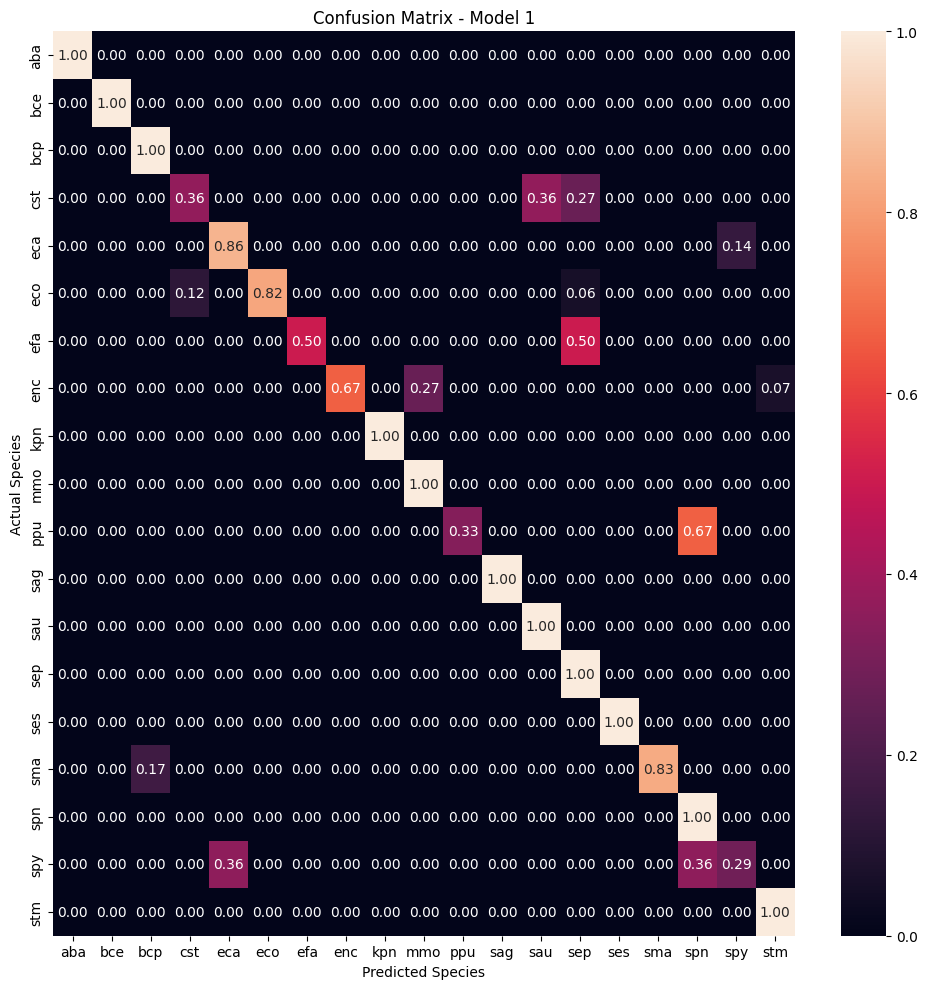

In [ ]:
plt.figure(figsize=(10,10))

sns.heatmap(
    cm1_normalised_df,
    annot=True,
    fmt=".2f"
)

plt.xlabel("Predicted Species")
plt.ylabel("Actual Species")
plt.title("Confusion Matrix - Model 1")

plt.tight_layout()
plt.show()

### 9.4.2 Model 2 — Confusion Matrix

In [ ]:
con_model2 = results_model2[["species","predicted_species","correct"]].copy()
con_model2

,species,predicted_species,correct
0,aba,aba,True
1,aba,aba,True
2,aba,aba,True
3,aba,aba,True
4,aba,aba,True
...,...,...,...
185,stm,stm,True
186,stm,stm,True
187,stm,stm,True
188,stm,stm,True


In [ ]:
species_names = sorted(con_model2["species"].unique())

cm2 = confusion_matrix(con_model2["species"],con_model2["predicted_species"],labels=species_names)
cm2

array([[10,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0],
       [ 0, 10,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0],
       [ 1,  0,  9,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0],
       [ 0,  0,  0,  9,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  0,  0,
         0,  0,  0],
       [ 0,  0,  0,  0,  7,  0,  3,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0],
       [ 0,  0,  0,  0,  0, 10,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0],
       [ 0,  0,  0,  0,  0,  0, 10,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0, 10,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0, 10,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0],
       [ 1,  0,  0,  0,  0,  0,  0,  0,  0,  9,  0,  0,  0,  0,  0,  0,
         0,  0,  0],
       [ 0,  0,  0,  0,  0,  1,  0,  0,  0,  0,  9,  0,  0,  0,  0,  0

In [ ]:
cm2_normalized = confusion_matrix(
    con_model2["species"],
    con_model2["predicted_species"],
    labels=species_names,
    normalize="true"
)

cm2_normalized

array([[1. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ,
        0. , 0. , 0. , 0. , 0. , 0. ],
       [0. , 1. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ,
        0. , 0. , 0. , 0. , 0. , 0. ],
       [0.1, 0. , 0.9, 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ,
        0. , 0. , 0. , 0. , 0. , 0. ],
       [0. , 0. , 0. , 0.9, 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ,
        0.1, 0. , 0. , 0. , 0. , 0. ],
       [0. , 0. , 0. , 0. , 0.7, 0. , 0.3, 0. , 0. , 0. , 0. , 0. , 0. ,
        0. , 0. , 0. , 0. , 0. , 0. ],
       [0. , 0. , 0. , 0. , 0. , 1. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ,
        0. , 0. , 0. , 0. , 0. , 0. ],
       [0. , 0. , 0. , 0. , 0. , 0. , 1. , 0. , 0. , 0. , 0. , 0. , 0. ,
        0. , 0. , 0. , 0. , 0. , 0. ],
       [0. , 0. , 0. , 0. , 0. , 0. , 0. , 1. , 0. , 0. , 0. , 0. , 0. ,
        0. , 0. , 0. , 0. , 0. , 0. ],
       [0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 1. , 0. , 0. , 0. , 0. ,
        0. , 0. , 0. , 0. , 0. 

In [ ]:
cm2_normalised_df = pd.DataFrame(
    cm2_normalized,
    index=species_names,
    columns=species_names
)

cm2_normalised_df

,aba,bce,bcp,cst,eca,eco,efa,enc,kpn,mmo,ppu,sag,sau,sep,ses,sma,spn,spy,stm
aba,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
bce,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
bcp,0.1,0.0,0.9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
cst,0.0,0.0,0.0,0.9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.1,0.0,0.0,0.0,0.0,0.0
eca,0.0,0.0,0.0,0.0,0.7,0.0,0.3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
eco,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
efa,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
enc,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
kpn,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
mmo,0.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


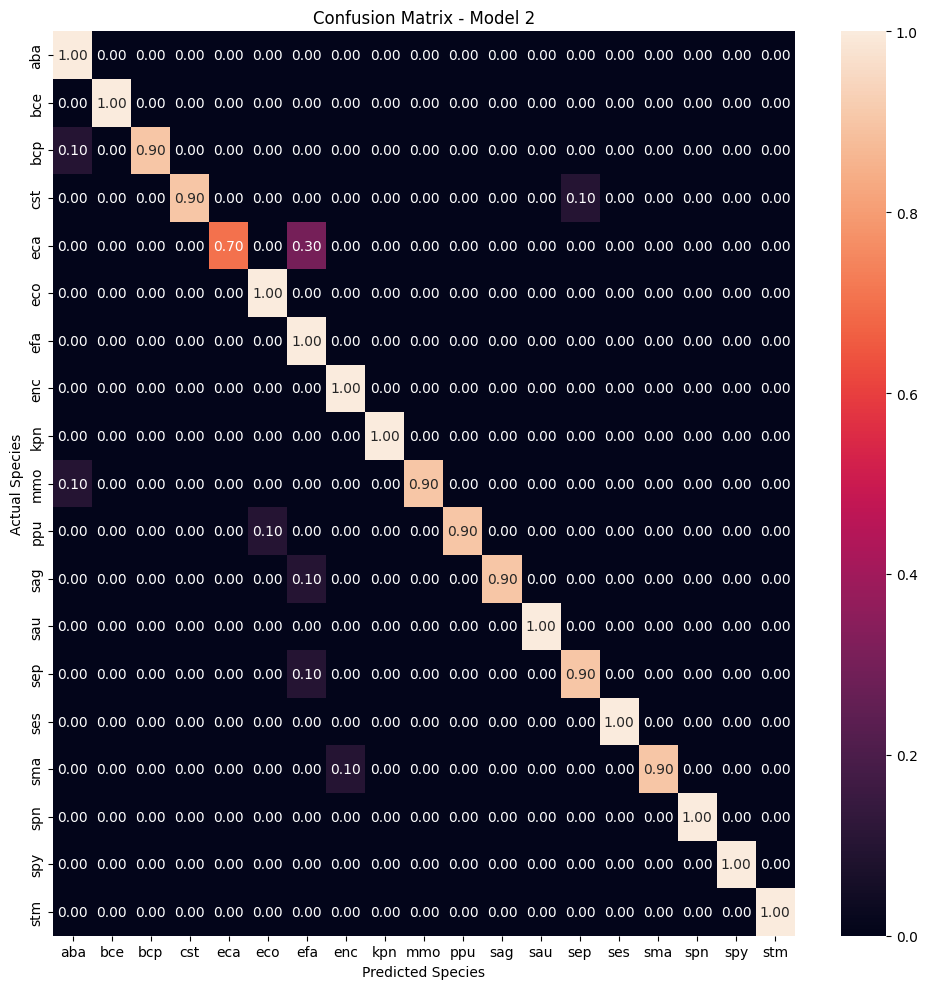

In [ ]:
plt.figure(figsize=(10,10))

sns.heatmap(
    cm2_normalised_df,
    annot=True,
    fmt=".2f"
)

plt.xlabel("Predicted Species")
plt.ylabel("Actual Species")
plt.title("Confusion Matrix - Model 2")

plt.tight_layout()
plt.show()

## 9.5 Model 1 — Generalization to Unseen Strains

This analysis evaluates how well Model 1 generalizes to individual bacterial strains that were not seen during training. It measures the model’s ability to recognize species from previously unseen strain-level variations, providing a more rigorous assessment of its generalization capability beyond the training data.

In [ ]:
len(results_model1.strain.unique())

29

In [ ]:
results_model1.columns

Index(['image_filename', 'original_filename', 'species', 'image_type',
       'augmentation', 'strain', 'split_Exp_A_strain', 'split_Exp_B_random',
       'predicted_species', 'confidence', 'correct'],
      dtype='object')

In [ ]:
results_model1

,image_filename,original_filename,species,image_type,augmentation,strain,split_Exp_A_strain,split_Exp_B_random,predicted_species,confidence,correct
0,aba_02.jpg,aba_02.jpg,aba,original,none,aba_02,test,test,aba,0.998403,True
1,aba_03.jpg,aba_03.jpg,aba,original,none,aba_02,test,train,aba,0.988470,True
2,aba_31.jpg,aba_31.jpg,aba,original,none,aba_02,test,train,aba,0.750025,True
3,aba_32.jpg,aba_32.jpg,aba,original,none,aba_02,test,train,aba,0.979981,True
4,aba_43.jpg,aba_43.jpg,aba,original,none,aba_11,test,train,aba,0.998253,True
...,...,...,...,...,...,...,...,...,...,...,...
181,stm_46.jpg,stm_46.jpg,stm,original,none,stm_05,test,train,stm,0.997278,True
182,stm_47.jpg,stm_47.jpg,stm,original,none,stm_05,test,test,stm,0.999263,True
183,stm_48.jpg,stm_48.jpg,stm,original,none,stm_05,test,test,stm,0.999555,True
184,stm_49.jpg,stm_49.jpg,stm,original,none,stm_05,test,train,stm,0.995795,True


In [ ]:
correct_per_strain = (
    results_model1[results_model1["correct"] == True]
    .groupby("strain")
    .size()
)

correct_per_strain

,0
strain,
aba_02,4
aba_11,4
bce_05,6
bcp_02,4
cst_06,4
eca_05,18
eco_05,13
eco_06,1
efa_02,1


In [ ]:
wrong_per_strain = (
    results_model1[results_model1["correct"] == False]
    .groupby("strain")
    .size()
)

wrong_per_strain

,0
strain,
cst_06,7
eca_05,3
eco_06,3
efa_06,1
enc_05,4
enc_07,1
ppu_02,2
sma_03,1
spy_01,10


In [ ]:
#axis=0 = downwards, add more rows
#axis=1 = sideways, add more columns

strain_counts = pd.concat(
    [correct_per_strain, wrong_per_strain],
    axis=1
)

strain_counts.columns = ["correct", "wrong"]

strain_counts = strain_counts.fillna(0)

strain_counts

,correct,wrong
strain,,
aba_02,4.0,0.0
aba_11,4.0,0.0
bce_05,6.0,0.0
bcp_02,4.0,0.0
cst_06,4.0,7.0
eca_05,18.0,3.0
eco_05,13.0,0.0
eco_06,1.0,3.0
efa_02,1.0,0.0


In [ ]:
strain_counts["accuracy"] = ( strain_counts["correct"] /

                             (strain_counts["correct"] + strain_counts["wrong"]) )

In [ ]:
strain_counts

,correct,wrong,accuracy
strain,,,
aba_02,4.0,0.0,1.000000
aba_11,4.0,0.0,1.000000
bce_05,6.0,0.0,1.000000
bcp_02,4.0,0.0,1.000000
cst_06,4.0,7.0,0.363636
eca_05,18.0,3.0,0.857143
eco_05,13.0,0.0,1.000000
eco_06,1.0,3.0,0.250000
efa_02,1.0,0.0,1.000000


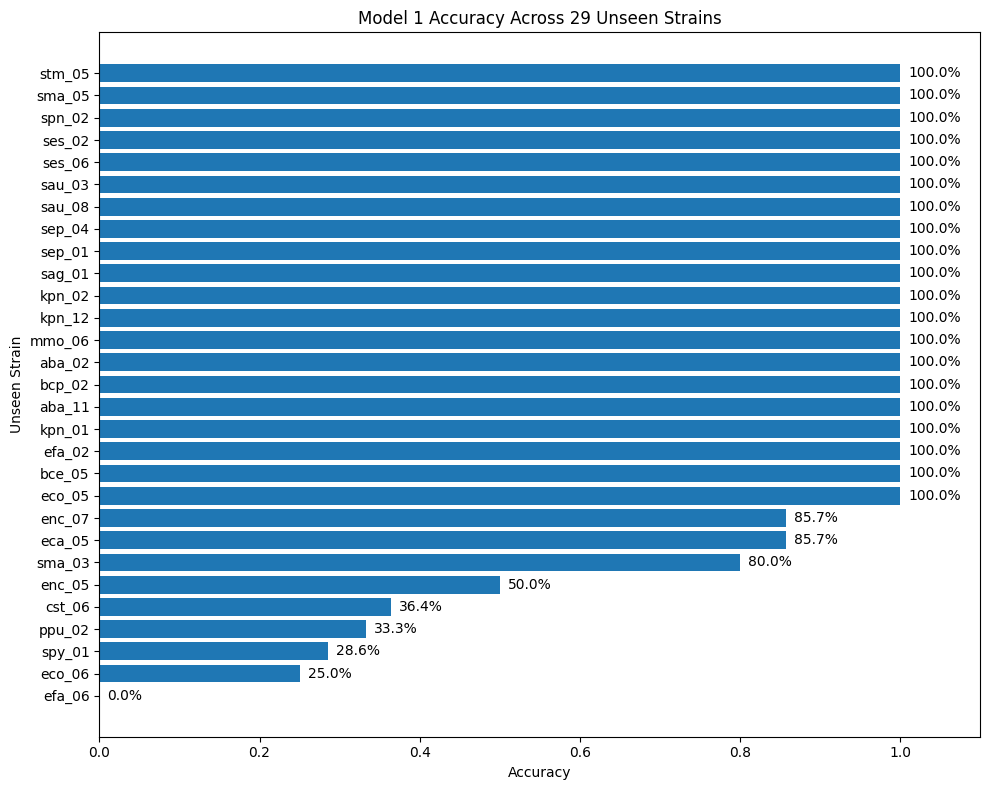

In [ ]:


# Sort strains by accuracy
strain_plot = strain_counts.sort_values("accuracy")

# Create the horizontal bar chart
plt.figure(figsize=(10, 8))

bars = plt.barh(
    strain_plot.index,
    strain_plot["accuracy"]
)

# Add accuracy values at the end of each bar
for bar in bars:
    plt.text(
        bar.get_width() + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{bar.get_width():.1%}",
        va="center"
    )

plt.xlabel("Accuracy")
plt.ylabel("Unseen Strain")
plt.title("Model 1 Accuracy Across 29 Unseen Strains")

plt.xlim(0, 1.1)
plt.tight_layout()
plt.show()

# 10. Conclusion



This project investigated the use of deep learning for automated classification of bacterial species from high resolution colony plate images. The study used the High Resolution Colony Images dataset containing 19 bacterial species and multiple clinically isolated strains. Complete plate images were retained rather than manually cropping individual colonies, allowing the model to learn visual characteristics directly from the overall plate image. A pretrained ResNet-18 convolutional neural network was adapted to the 19 class classification problem using transfer learning, preprocessing, augmentation, and controlled finetuning.

Two experimental settings were developed to examine model performance under different generalization conditions. **Model 1** used a strain level split, where bacterial strains present in the test set were not used during training. This provided a more challenging evaluation of whether the learned visual features could generalize to previously unseen strains. **Model 2** used a random image level split, representing a conventional classification setting in which images from the same strain distribution could occur in both training and testing data.

The results demonstrated that the ResNet-18 model was able to learn meaningful visual representations for bacterial species classification. Model 1 achieved **82.80% test accuracy**, while Model 2 achieved **94.74% test accuracy**. The higher performance of Model 2 compared with Model 1 demonstrates that classification becomes substantially more difficult when the model encounters previously unseen strains. This indicates that within species morphological variation is an important factor affecting model generalization.

The class level evaluation using precision, recall, F1-score, and confusion matrices further showed that classification performance was not uniform across all bacterial species. Some species were consistently recognized with high accuracy, while others produced more misclassifications, particularly under the unseen strain condition. These results demonstrate that overall accuracy alone is insufficient for evaluating a biological image classification system and that class specific performance must also be considered.

Overall, the project demonstrates the feasibility of using a pretrained CNN for automated bacterial colony image classification while highlighting the importance of biologically meaningful dataset splitting and evaluation. The comparison between the two experiments shows that a high random image level accuracy does not necessarily indicate equivalent performance on unseen bacterial strains. Therefore, **strain level generalization provides a more demanding and informative assessment of the robustness of bacterial image classification**. The trained models provide a foundation for the final deployment stage, where the same preprocessing and inference pipeline can be integrated into a practical application for automated bacterial species prediction.


#11. References



**[1] Original Dataset Paper**

Du, J., Yang, C., Sun, M., Sun, Q., Wang, M., Ji, X., Wang, K., & Xu, J. (2026).  
*High-Resolution Colony Images of Clinically Isolated Bacteria for Automated Detection and Deep Learning.*  
Scientific Data, 13, 757.  

DOI: https://doi.org/10.1038/s41597-026-07095-5


**[2] Dataset**

Jia, D. (2026).  
*Clinical Dataset of 19 Bacterial Colony Images.*  
Zenodo.  

Dataset DOI: https://doi.org/10.5281/zenodo.18256864


**[3] Dataset Code Repository**

Dataset19 — Python scripts for image augmentation, annotation conversion, statistical analysis, and annotation validation.

GitHub: https://github.com/jia-1680/Dataset19


**[4] ResNet-18**

He, K., Zhang, X., Ren, S., & Sun, J. (2016).  
*Deep Residual Learning for Image Recognition.*  
Proceedings of the IEEE Conference on Computer Vision and Pattern Recognition (CVPR), 770–778.

DOI: https://doi.org/10.1109/CVPR.2016.90